### 3D Forward $NVT$ Simualtion with Patchy Particles
In this sample script, we demonstrate how to create patchy particles with different geometries and patch types using the `rigid_body` class in JAX-MD and run forward MD simulations. Throughout the script, we will provide helper functions to reconstruct the full patchy particle using the position and orientation of the center of mass of the patchy particle, and showcase how to use $Q_l$ order parameters to measure the formation of a simple cubic structure.

#### 1. Standard Import

In [2]:
import numpy as onp

from jax import config
config.update('jax_enable_x64', True)

import jax.numpy as jnp
from jax import scipy
from jax import random, jit, lax, vmap, jacfwd, remat
from jax.example_libraries import optimizers

import time
import os
from jax_md import space, smap, energy, minimize, quantity, simulate, rigid_body

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.collections import EllipseCollection
import seaborn as sns

sns.set_style(style='white')

def format_plot(x, y):
  plt.xlabel(x, fontsize=20)
  plt.ylabel(y, fontsize=20)

def finalize_plot(shape=(1, 1)):
  plt.gcf().set_size_inches(
    shape[0] * 1.5 * plt.gcf().get_size_inches()[1],
    shape[1] * 1.5 * plt.gcf().get_size_inches()[1],
  )
  plt.tight_layout()

#### 2. Loss Function ($Q_l$)
For detailed explanation of how to use $Q_l$, see notebook `loss_functions.ipynb`.

In [35]:
def get_Q_l(displacement_all, l = 6, r0 = 1.1, alpha = 100):

  def Ylm(theta, phi):
    m = jnp.arange(-l, l + 1)
    return scipy.special.sph_harm_y(jnp.array([l]), m, 
                                    jnp.array([theta]), jnp.array([phi]))

  def get_ylms(dR_ij):
    epsilon = 0.00001 #avoids nan in derivative
    dR_ij = jnp.where(dR_ij==0.0, epsilon, dR_ij)
    phi = jnp.arctan2(dR_ij[1], dR_ij[0])
    rsin = jnp.sqrt(dR_ij[0]**2 + dR_ij[1]**2)
    theta = jnp.arctan2(rsin, dR_ij[2])
    return Ylm(theta, phi)

  def weight(r):
    return jnp.where(r<1e-7, 0., 1.0/(1 + jnp.exp(alpha*(r - r0))))

  def calculate_order_param(R):
    v_get_ylms = vmap(vmap(get_ylms))
    ds = displacement_all(R, R)
    r = space.distance(ds)
    w = jnp.expand_dims(weight(r), -1)
    q_lm = (jnp.sum(v_get_ylms(ds)*w, axis=0)/(jnp.sum(w, axis=0)+0.000001)).reshape(-1,1,l*2+1)
    q_lm_broad = jnp.repeat(q_lm, repeats=len(q_lm), axis=1)
    ave_q_lm = jnp.sum(q_lm_broad*w, axis=0)/(jnp.sum(w, axis=0)+0.000001)
    Qlm_each_particle = jnp.sqrt(4*jnp.pi*jnp.abs(jnp.einsum('...m, ...m', jnp.conj(ave_q_lm), ave_q_lm))/(l*2+1))
    return jnp.mean(Qlm_each_particle)

  return calculate_order_param

#### 3. Structure Builder Helper Function
For detailed explanation of how to use the 2D/3D structure initializer, see notebook `structures_init.ipynb`.

In [22]:
def make_3D_lattice_from_index_list(index_list,
                                    a0=jnp.array([jnp.sqrt(2),0.0,0.0]),
                                    a1=jnp.array([0.0,jnp.sqrt(2),0.0]),
                                    a2=jnp.array([0.0,0.0,jnp.sqrt(2)]),
                                    unitcell=jnp.array([[0.0, 0.0, 0.0]]),
                                    offset=jnp.array([0.0,0.0,0.0])):
  unitcell_particles = unitcell + offset
  N = len(unitcell_particles)*index_list.shape[0]
  def get_cell(i,j,k):
    cell_shift = i*a0+j*a1+k*a2
    return unitcell_particles + cell_shift

  return jnp.reshape(vmap(get_cell, in_axes=(0,0,0))(index_list[:,0],index_list[:,1],index_list[:,2]),(N,3))

make_3D_lattice_from_index_list = jit(make_3D_lattice_from_index_list)

def make_3D_lattice(irange, jrange, krange, **kwargs):
  index_list = jnp.array([ [i,j,k] for i in irange for j in jrange for k in krange])
  return make_3D_lattice_from_index_list(index_list, **kwargs)

make_3D_lattice = jit(make_3D_lattice)

#### 4. Rigid Body Setup Helper Functions
Here we simulate a type of patchy particles where the center circle serves as the body, and patches around the body particle serve as the interaction sites. Here, we consider the patches massless. 
* We use angles (`thetas`) to define the location of the patches, the first patch is always at `[1, 0]` in the rigid body reference frame.
* All patches can be the same species or different species, we use `species` to define the species of all patches. The body particle will always have species 0, and the patch species start at 1.
* `radius` defines the size of the body particle
* `center_mass` defines the mass of the body particle
* `patch_mass` defines the mass of the patches, for most of the simulation considered here, they are practically massless.

In [14]:
@jit
def thetas_to_shape(thetas_and_phis, species, radius=0.5, center_mass=1.0, patch_mass=1e-5):
  # Convert angles to patch positions
  thetas = thetas_and_phis[:NUM_PATCHES]
  phis = thetas_and_phis[NUM_PATCHES:]
  patch_positions = jnp.zeros((NUM_PATCHES, 3), dtype = jnp.float64)
  patch_positions = patch_positions.at[:, 0].set(radius*jnp.cos(phis)*jnp.sin(thetas))
  patch_positions = patch_positions.at[:, 1].set(radius*jnp.sin(phis)*jnp.sin(thetas)) 
  patch_positions = patch_positions.at[:, 2].set(radius*jnp.cos(thetas))

  # Add the central particle (position (0, 0)) to the list of positions
  central_particle_position = jnp.array([[0.0, 0.0, 0.0]])
  positions = jnp.concatenate((central_particle_position, patch_positions), axis=0)

  if not len(thetas)+1 == len(species):
    raise ValueError("Must provide species information for every particle")

  # Combine positions and species to form a patchy particle rigid_body object
  masses = jnp.array([center_mass] + len(thetas)*[patch_mass])
  shape = rigid_body.point_union_shape(positions, masses).set(point_species=species)
  return shape

`body_to_plot` helps us recover the positions of all particles and group positions for the same patch species in the simulation for the ease of plot. During the simulation, the only position information recorded are the center of mass particles position and orientation.

In [4]:
def body_to_plot(body, thetas_and_phis, species, radius=0.5):
  shape = thetas_to_shape(thetas_and_phis, species, radius=radius)
  body_pos = vmap(rigid_body.transform, (0, None))(body, shape)
  bodypos = body_pos.reshape(-1, 3)
  species_list = jnp.array(list(species) * len(body.center))

  inds_at_id = lambda id: jnp.squeeze(jnp.argwhere(species_list==id))
  center_particles = bodypos[inds_at_id(0)]
  list_of_patch_particles = []
  for i in range(1, len(species)):
    list_of_patch_particles += [bodypos[inds_at_id(i)]]

  return center_particles, list_of_patch_particles

#### 5. Setting Up the Simulation
Here, we will set up a simulation with 125 patchy particles, each has six patches at $[\theta, \phi] = [[0, 0], [90, 90], [180, 0], [90, 270], [90, 0], [90, 180]]$. 

We will initialize the system on a dilute 5x5x5 ($M$) square lattice with lattice spacings $A = 1.5$.

The simulation will have a number density $\rho=0.3$.

Our goal is to assemble a simple cubic structure.

In [20]:
### Global Parameters
M = 5
A = 1.5
A0_sc = jnp.array([A, 0, 0])
A1_sc = jnp.array([0, A, 0])
A2_sc = jnp.array([0, 0, A])
UNITCELL_sc = jnp.array([[0.0, 0.0, 0.0]])

N = M**3
DIMENSION = 3

RHO = 0.3
BOX_SIZE = (N/RHO)**(1/DIMENSION)

kT = 0.2
dt = 1e-3
RADIUS = 0.5
R0 = RADIUS*2*1.1
NUM_PATCHES = 6
THETAS_AND_PHIS = jnp.array([0, jnp.pi/2.0, jnp.pi, jnp.pi/2.0, jnp.pi/2.0, jnp.pi/2.0,
                             0, jnp.pi/2.0, 0, jnp.pi*3/2.0, 0, jnp.pi])
SPECIES = jnp.array([0, 1, 2, 3, 4, 5, 6], dtype = jnp.int32)
NUM_SPECIES = len(set(list(onp.array(SPECIES))))

key=random.PRNGKey(125)

In [23]:
R = (make_3D_lattice)(jnp.arange(0,M),jnp.arange(0,M),jnp.arange(0,M),
                      a0 = A0_sc,
                      a1 = A1_sc,
                      a2 = A2_sc,
                      unitcell= UNITCELL_sc,
                      offset=jnp.array([0.01, 0.02, 0.03]))

Here, we will visualize the initialization setup for our system. First, the body particles only, and then the full patchy particle realization.

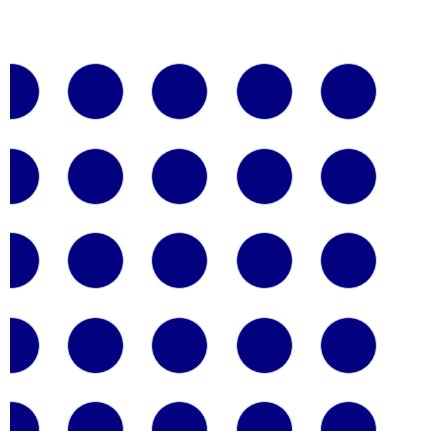

In [24]:
fig, ax = plt.subplots()
fig.set_size_inches(3, 3)
ax.add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(R[:,:2]), transOffset=ax.transData))
plt.xlim([0, BOX_SIZE])
plt.ylim([0, BOX_SIZE])
plt.axis('off')
finalize_plot((1, 1))

In [31]:
# Conver to rigid body object
patchy_particle_shape = thetas_to_shape(THETAS_AND_PHIS, SPECIES)

# Choose random orientations for each patchy particle
angle_key, split = random.split(key)
angles = random.uniform(angle_key, (len(R),), dtype=jnp.float64) * jnp.pi * 2
orientations = jnp.zeros((len(R), 4), dtype = jnp.float64)
orientations = orientations.at[:, 0].set(jnp.cos(angles))
orientations = orientations.at[:, 3].set(jnp.sin(angles))
orientations = rigid_body.Quaternion(orientations)

# Combine orientations with square lattice positions
full_configuration = rigid_body.RigidBody(R, orientations)
     

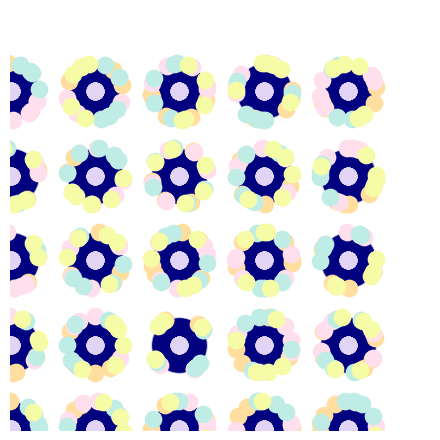

In [32]:
fig, ax = plt.subplots()
fig.set_size_inches(3, 3)
center_pos, patches_pos = body_to_plot(full_configuration, THETAS_AND_PHIS, SPECIES)
patches_color = ['#e1d4f4', '#ffde9f', '#e1d4f4', '#ffdfee', '#bfede6', '#f6fca6']
ax.add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(center_pos[:,:2]), transOffset=ax.transData))
for i in range(1, NUM_SPECIES):
  ax.add_collection(EllipseCollection(widths=0.29, heights=0.29, angles=0, units='xy',
                                      facecolors=patches_color[i-1], edgecolors=patches_color[i-1], alpha = 1.0, 
                                      offsets=list(patches_pos[i-1][:,:2]), transOffset=ax.transData))
plt.xlim([0, BOX_SIZE])
plt.ylim([0, BOX_SIZE])
plt.axis('off')
finalize_plot((1, 1))

Here, we define our pair potentials and integrator to run the simulation.
* We use `soft_sphere` potential to define the excluded volume of the body particle.
* We use `morse` potential to define the attractiveness of the patches
    * `sigma` defines the minimum of the `morse` potential well. Here we assume our patches interact by fully overlap, so `sigma=0`.
    * `alpha` defines the steepness of the `morse` potential, representing the interaction range of the patches. `alpha=9.0` roughly represents an interaction range of 0.29.

In [33]:
displacement, shift = space.periodic(BOX_SIZE)
key, split = random.split(key)

soft_eps = jnp.zeros((NUM_SPECIES, NUM_SPECIES))
soft_eps = soft_eps.at[0, 0].set(10000.0)
morse_eps = jnp.zeros((NUM_SPECIES, NUM_SPECIES))
morse_eps = morse_eps.at[1, 3].set(4.0)
morse_eps = morse_eps.at[3, 1].set(4.0)
morse_eps = morse_eps.at[2, 4].set(4.0)
morse_eps = morse_eps.at[4, 2].set(4.0)
morse_eps = morse_eps.at[5, 6].set(4.0)
morse_eps = morse_eps.at[6, 5].set(4.0)
energy_fn_soft = energy.soft_sphere_pair(displacement, species = NUM_SPECIES, sigma = RADIUS*2, epsilon = soft_eps, alpha = 4.0)
energy_fn_morse = energy.morse_pair(displacement, species = NUM_SPECIES, sigma = 0.0, epsilon = morse_eps, alpha = 9.0, r_cutoff = 1.5)
energy_fn_all = lambda R, **kwargs: energy_fn_soft(R, **kwargs) + energy_fn_morse(R, **kwargs)
energy_fn = rigid_body.point_energy(energy_fn_all, patchy_particle_shape)
energy_fn = jit(energy_fn)

init, apply = simulate.nvt_nose_hoover(energy_fn, shift, dt, kT = kT)
step = jit(lambda i, state: apply(state))
state = init(key, full_configuration, mass=patchy_particle_shape.mass())

#### 6. Running the Simulation
Here, we will run the simulation for a total of `N_stepsxinner_steps=1000x100=1e5` steps. 

We will also record the following thermodynamics variables:
* Potential Energy (`PE`): this can be directly calculated using `energy_fn`
* Kinetic Energy (`KE`): we need to use the `rigid_body.kinetic_energy` function instead of the `quantity.kinetic_energy` as we have rotational degree of freedom. We will need to provide `position, moment, mass` data for correct computation.
* Temperature (`T`): we need to use the `rigid_body.temperature` function instead of the `quantity.temperature` as we have rotational degree of freedom. We will need to provide `position, moment, mass` data for correct computation.
* `loss`: we will record $\psi_4$ order parameter along the simulation
* `trajectory`: position data of the body particle

In [36]:
displacement_all = vmap(vmap(displacement, (0, None), 0), (None, 0), 0)
order_param = get_Q_l(displacement_all, l=4, r0=R0, alpha=100)

PE = [energy_fn(state.position)]
KE = [rigid_body.kinetic_energy(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
T = [rigid_body.temperature(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
loss = [order_param(state.position.center)]
trajectory = [state.position]

N_steps = 1000
inner_steps = 100
print_every = 100
old_time = time.time()
print('Step\tKE\tPE\tTotal Energy\ttime/step')
print('----------------------------------------')

for i in range(N_steps):
  state = lax.fori_loop(0, inner_steps, step, state)

  PE += [energy_fn(state.position)]
  KE += [rigid_body.kinetic_energy(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
  T += [rigid_body.temperature(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
  loss += [order_param(state.position.center)]
  trajectory += [state.position]

  if i % print_every == 0 and i > 0:
    new_time = time.time()
    print(
      '{}\t{:.2f}\t{:.2f}\t{:.3f}\t{:.3f}'.format(
        i * inner_steps,
        KE[-1],
        PE[-1],
        KE[-1] + PE[-1],
        (new_time - old_time) / print_every / inner_steps,
      )
    )
    old_time = new_time

PE = jnp.array(PE)
KE = jnp.array(KE)
T = jnp.array(T)
loss = jnp.array(loss)

Step	KE	PE	Total Energy	time/step
----------------------------------------
10000	77.47	-654.04	-576.571	0.002
20000	84.02	-756.15	-672.127	0.002
30000	75.80	-800.85	-725.055	0.002
40000	74.44	-809.78	-735.341	0.002
50000	68.35	-806.28	-737.924	0.002
60000	74.19	-817.94	-743.741	0.002
70000	78.39	-824.76	-746.367	0.002
80000	70.93	-824.63	-753.707	0.002
90000	71.19	-828.48	-757.290	0.002


#### 7. Visualize the Results

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_743762/1828304066.py:17: SyntaxWarning: invalid escape sequence '\p'
  axs[2].set_ylabel('$\psi_4$', fontsize = 18)


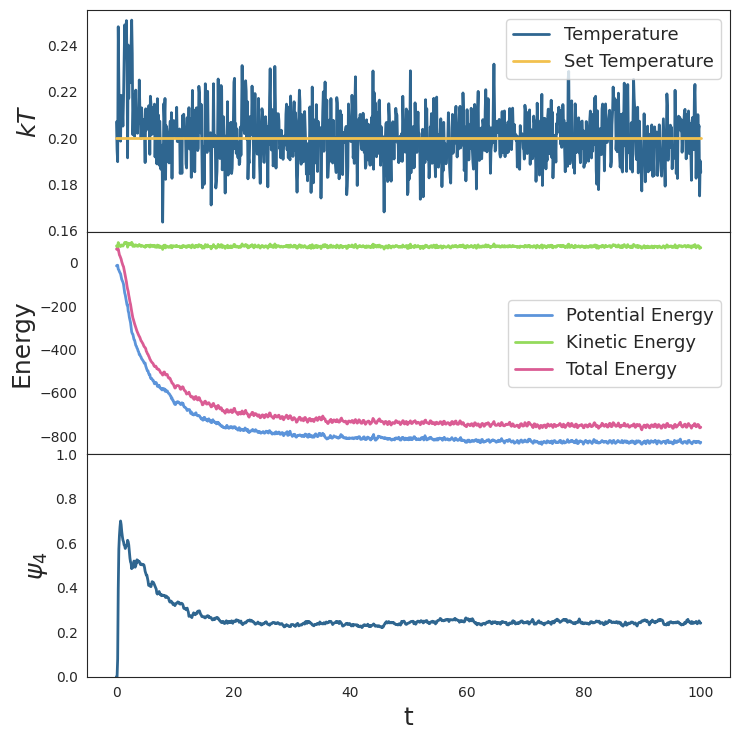

In [37]:
t = onp.arange(0, N_steps+1) * dt * inner_steps

fig = plt.figure(figsize = (8, 5))
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True)

axs[0].plot(t, T, label = 'Temperature', color = '#2f6690', linewidth = 2)
axs[0].plot(t, onp.ones(len(t))*0.2, color = '#f2c14e', label = 'Set Temperature', linewidth = 2)
axs[0].legend(fontsize = 13)
axs[0].set_ylabel('$kT$', fontsize = 18)
axs[1].plot(t, PE, label='Potential Energy', color = '#5c94da', linewidth = 2)
axs[1].plot(t, KE, label='Kinetic Energy', color = '#94da5c', linewidth = 2)
axs[1].plot(t, PE + KE, label='Total Energy', color = '#da5c94', linewidth = 2)
axs[1].legend(fontsize = 13)
axs[1].set_ylabel('Energy', fontsize = 18)
axs[2].plot(t, loss, color = '#2f6690', linewidth = 2)
axs[2].set_ylabel('$\psi_4$', fontsize = 18)
axs[2].set_ylim(0.0, 1.0)
axs[2].set_xlabel('t', fontsize = 18)
finalize_plot()

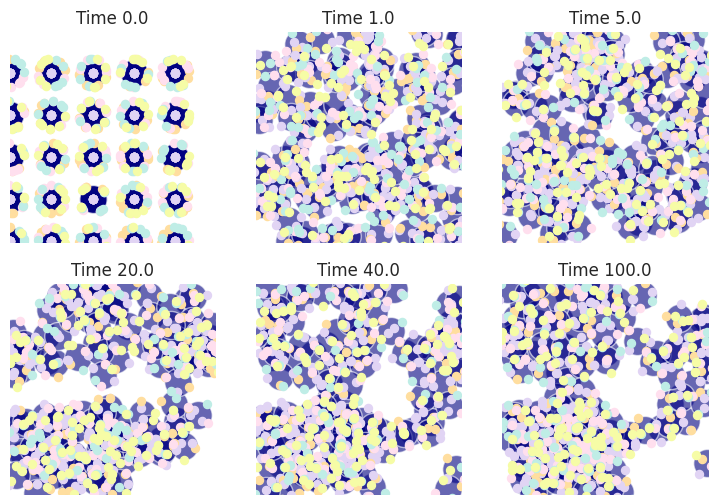

In [40]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(9, 6)
index = [0, 10, 50, 200, 400, 1000]
patches_color = ['#e1d4f4', '#ffde9f', '#e1d4f4', '#ffdfee', '#bfede6', '#f6fca6']
for i in range(2):
  for j in range(3):
    center_pos, patches_pos = body_to_plot(trajectory[index[i*3+j]], THETAS_AND_PHIS, SPECIES)

    axs[i, j].add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                           facecolors='navy', alpha = 0.6, 
                                           offsets=list(center_pos[:,:2]), transOffset=axs[i, j].transData))
    for k in range(1, NUM_SPECIES):
      axs[i, j].add_collection(EllipseCollection(widths=0.29, heights=0.29, angles=0, units='xy',
                                      facecolors=patches_color[k-1], edgecolors=patches_color[k-1], alpha = 1.0, 
                                      offsets=list(patches_pos[k-1][:,:2]), transOffset=axs[i, j].transData))

    axs[i, j].set_xlim([0, BOX_SIZE])
    axs[i, j].set_ylim([0, BOX_SIZE])
    axs[i, j].set_axis_off()
    axs[i, j].set_title("Time "+str(index[i*3+j]*dt*inner_steps))

### 8. Visualization using INJAVIS (https://engellab.de/teaching/injavis/)
Here we also provide a short script if you wish to visualize your simulation results using INJAVIS.

In [41]:
pos_file = "cube.pos"
L = BOX_SIZE
patches_color = ['#e1d4f4', '#ffde9f', '#e1d4f4', '#ffdfee', '#bfede6', '#f6fca6']

with open(pos_file, 'a') as outfile:
    for frame in trajectory[0::100]:
        outfile.write('boxMatrix '+str(L)+' 0 0 0 '+str(L)+' 0 0 0 '+str(L)+' \n')
        outfile.write('def A "sphere 1.0 b9b2d8" \n')
        for k in range(1, NUM_SPECIES):
            outfile.write('def P'+str(k)+' "sphere 0.29 '+patches_color[k-1]+'" \n')
        center_pos, patches_pos = body_to_plot(frame, THETAS_AND_PHIS, SPECIES)
        for pos in center_pos:
            position = pos
            entry = 'A ' + str(position[0]) + ' ' + str(position[1]) + ' ' + str(position[2]) + '\n'
            outfile.write(entry)
        for k in range(1, NUM_SPECIES):
            for pos in patches_pos[k-1]:
                position = pos
                entry = 'P' + str(k) + ' ' + str(position[0]) + ' ' + str(position[1]) + ' ' + str(position[2]) + '\n'
                outfile.write(entry)
    
        outfile.write('eof \n')